In [53]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


file_path = "../data/customer_shopping_data.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")

 
print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (99457, 10)
Sütun Adları: ['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'invoice_date', 'shopping_mall']


In [54]:
display(df.head())

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [55]:
df.info()
print("Dublikat sətir:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB
Dublikat sətir: 0


In [56]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='mixed', dayfirst=True)

print(df['invoice_date'].dtypes)
print(df['invoice_date'].head())

df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month

datetime64[us]
0   2022-08-05
1   2021-12-12
2   2021-11-09
3   2021-05-16
4   2021-10-24
Name: invoice_date, dtype: datetime64[us]


In [57]:
df['revenue'] = df['quantity'] * df['price']

In [58]:
categoryy_analysis= df.groupby('category').agg(
    total_revenue=('revenue','sum'),
    order_count=('invoice_no','count')  
).reset_index().sort_values(by='total_revenue', ascending=False)

print(categoryy_analysis)

          category  total_revenue  order_count
1         Clothing   1.139968e+08        34487
4            Shoes   6.655345e+07        10034
6       Technology   5.786235e+07         4996
2        Cosmetics   6.792863e+06        15097
7             Toys   3.980426e+06        10087
3  Food & Beverage   8.495351e+05        14776
0            Books   8.345529e+05         4981
5         Souvenir   6.358247e+05         4999


In [59]:
shopping_mall_analysis= df.groupby('shopping_mall').agg(
    total_revenue=('revenue','sum'),
    order_count=('invoice_no','count')
).reset_index().sort_values(by='total_revenue', ascending=False)

print(shopping_mall_analysis)

       shopping_mall  total_revenue  order_count
5   Mall of Istanbul    50872481.68        19943
4             Kanyon    50554231.10        19823
6          Metrocity    37302787.33        15011
7       Metropol AVM    25379913.19        10161
3       Istinye Park    24618827.68         9781
9       Zorlu Center    12901053.82         5075
0        Cevahir AVM    12645138.20         4991
8     Viaport Outlet    12521339.72         4914
1  Emaar Square Mall    12406100.29         4811
2     Forum Istanbul    12303921.24         4947


In [60]:
payment_method_analysis= df.groupby('payment_method').agg(
    total_revenue=('revenue','sum'),
    order_count=('invoice_no','count')
).reset_index().sort_values(by='total_revenue', ascending=False)

print(payment_method_analysis)

  payment_method  total_revenue  order_count
0           Cash   1.128322e+08        44447
1    Credit Card   8.807712e+07        34931
2     Debit Card   5.059643e+07        20079


In [61]:
gender_analysis= df.groupby('gender').agg(
    total_revenue=('revenue','sum'),
    order_count=('invoice_no','count')
).reset_index().sort_values(by='total_revenue', ascending=False)

print(gender_analysis)

   gender  total_revenue  order_count
0  Female   1.502071e+08        59482
1    Male   1.012987e+08        39975


In [62]:
bins = [17, 25, 35, 45, 55, 70]
labels = ['18-25','26-35','36-45','46-55','56-70']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
df.groupby('age_group', observed=True)['revenue'].agg(['sum','mean','count'])

,sum,mean,count
age_group,,,
18-25,38118271.35,2481.819868,15359
26-35,47879659.58,2512.181100,19059
36-45,50184235.79,2582.024891,19436
46-55,48219742.64,2535.745827,19016
56-70,67103884.89,2523.935942,26587


In [63]:
mall_avg = df.groupby('shopping_mall').agg(
    total_revenue=('revenue','sum'),
    order_count=('invoice_no','count')
).reset_index()
mall_avg['avg_order_value'] = mall_avg['total_revenue'] / mall_avg['order_count']
mall_avg.sort_values('avg_order_value', ascending=False)

,shopping_mall,total_revenue,order_count,avg_order_value
1,Emaar Square Mall,12406100.29,4811,2578.694718
5,Mall of Istanbul,50872481.68,19943,2550.894132
4,Kanyon,50554231.10,19823,2550.281547
8,Viaport Outlet,12521339.72,4914,2548.095181
9,Zorlu Center,12901053.82,5075,2542.079570
0,Cevahir AVM,12645138.20,4991,2533.588099
3,Istinye Park,24618827.68,9781,2517.005181
7,Metropol AVM,25379913.19,10161,2497.777108
2,Forum Istanbul,12303921.24,4947,2487.148017
6,Metrocity,37302787.33,15011,2485.030133


       category  Avg_Price_Per_Item  Avg_Total_Purchase  Total_Revenue  Revenue_Rank
       Clothing          901.084021         3305.500364   113996791.04             1
          Shoes         1807.388568         6632.793649    66553451.47             2
     Technology         3156.935548        11581.735388    57862350.00             3
      Cosmetics          122.448626          449.947864     6792862.90             4
           Toys          107.733185          394.609521     3980426.24             5
Food & Beverage           15.671948           57.494251      849535.05             6
          Books           45.568621          167.547260      834552.90             7
       Souvenir           34.894345          127.190368      635824.65             8


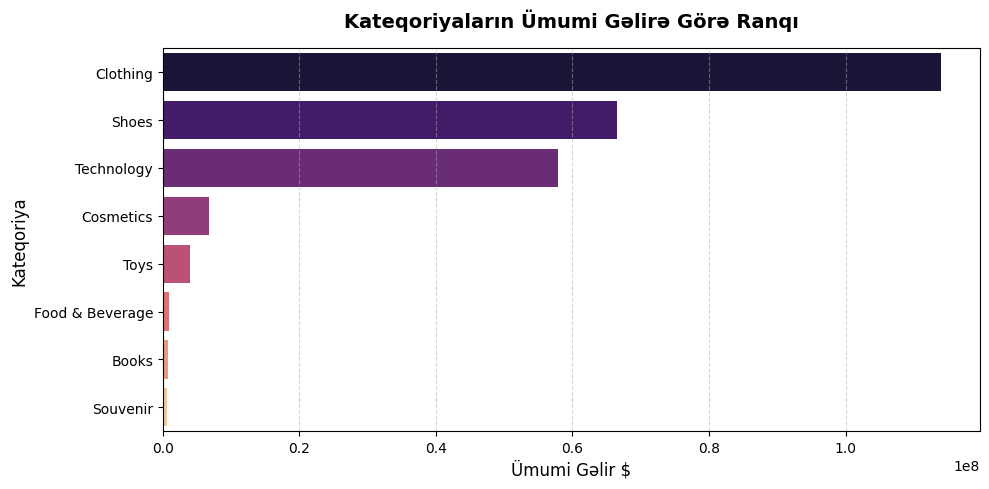

In [64]:

category_analysis = df.groupby('category').agg(
    Avg_Price_Per_Item=('price', 'mean'),             
    Avg_Total_Purchase=('revenue', 'mean'),     
    Total_Revenue=('revenue', 'sum')         
).reset_index()


category_analysis = category_analysis.sort_values(by='Total_Revenue', ascending=False)
category_analysis['Revenue_Rank'] = range(1, len(category_analysis) + 1)


print(category_analysis.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=category_analysis,
    x='Total_Revenue',
    y='category',
    palette='magma',
    hue='category',
    legend=False
)

plt.title('Kateqoriyaların Ümumi Gəlirə Görə Ranqı', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Ümumi Gəlir $', fontsize=12)
plt.ylabel('Kateqoriya', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

category               Books     Clothing   Cosmetics  Food & Beverage  \
shopping_mall                                                            
Cevahir AVM         44541.00   5706321.28   321214.00         44010.45   
Emaar Square Mall   41995.80   5590490.40   338941.76         40610.95   
Forum Istanbul      42056.40   5792444.24   353172.76         39162.24   
Istinye Park        76083.30  11253900.24   655357.88         85918.44   
Kanyon             163029.15  22609527.60  1369550.78        166497.05   
Mall of Istanbul   172240.35  22947417.68  1367517.78        171177.90   
Metrocity          125911.65  17226692.56   991860.04        129902.74   
Metropol AVM        83718.90  11568084.00   680770.38         88638.04   
Viaport Outlet      39632.40   5604594.16   347439.70         41662.18   
Zorlu Center        45343.95   5697318.88   367037.82         41955.06   

category                 Shoes   Souvenir  Technology       Toys  
shopping_mall                               

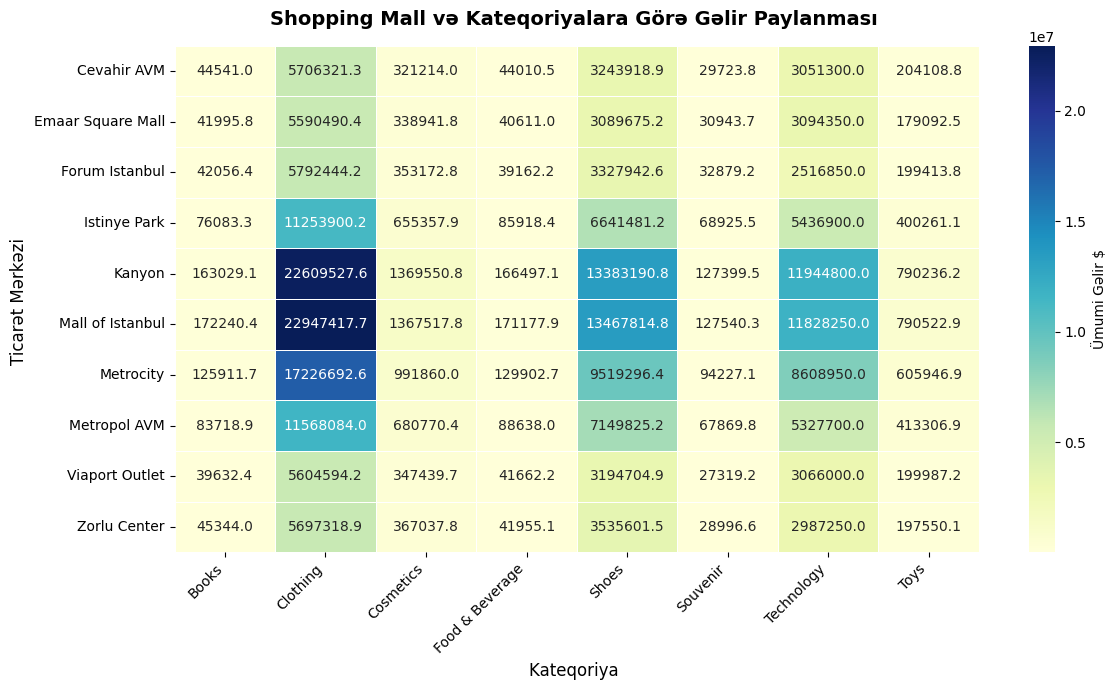

In [65]:
mall_category_pivot = df.pivot_table(
    index='shopping_mall', 
    columns='category', 
    values='revenue', 
    aggfunc='sum',
    fill_value=0  )


print(mall_category_pivot)

plt.figure(figsize=(12, 7))
sns.heatmap(
    mall_category_pivot, 
    annot=True,          
    fmt=".1f",           
    cmap="YlGnBu",     
    linewidths=0.5,
  cbar_kws={'label': 'Ümumi Gəlir $'}
)

plt.title('Shopping Mall və Kateqoriyalara Görə Gəlir Paylanması ', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Kateqoriya ', fontsize=12)
plt.ylabel('Ticarət Mərkəzi ', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()





year                    2021         2022        2023
category                                             
Books              369008.55    391945.65    73598.70
Clothing         52604924.24  51753897.36  9637969.44
Cosmetics         3033723.92   3150499.44   608639.54
Food & Beverage    390848.36    386852.64    71834.05
Shoes            30125533.15  30944765.20  5483153.12
Souvenir           288288.21    295865.79    51670.65
Technology       25951800.00  26651100.00  5259450.00
Toys              1796444.16   1861888.00   322094.08


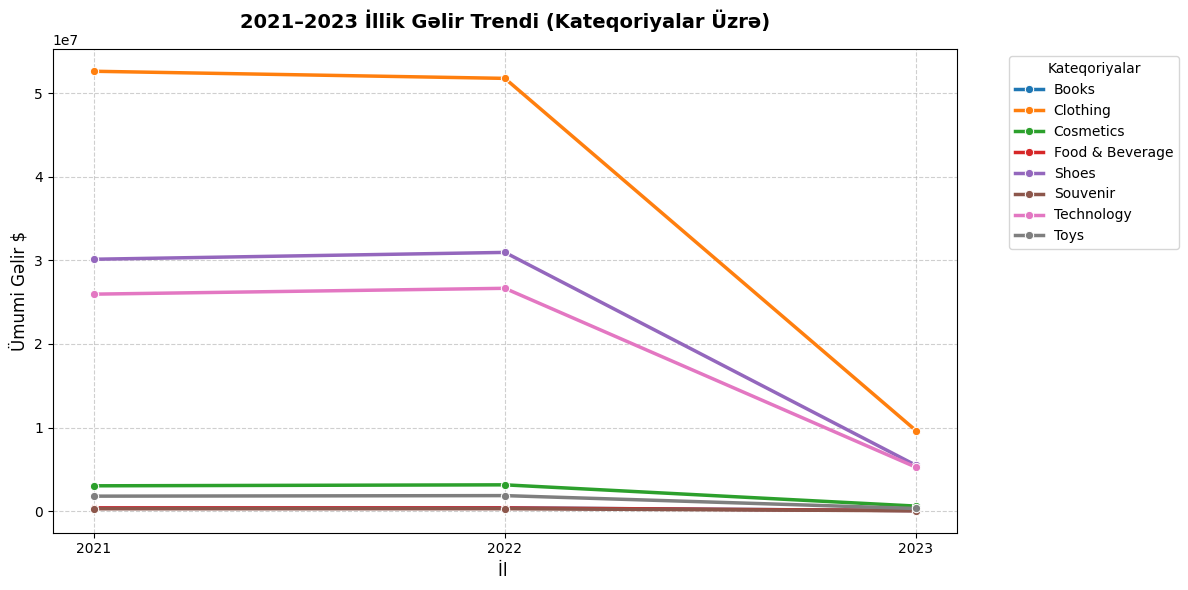

In [66]:
df_filtered = df[df['year'].isin([2021, 2022, 2023])]
yearly_category_revenue = df_filtered.groupby(['year', 'category'])['revenue'].sum().reset_index()
yearly_pivot = yearly_category_revenue.pivot(index='category', columns='year', values='revenue')
print(yearly_pivot)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_category_revenue, 
    x='year', 
    y='revenue', 
    hue='category', 
    marker='o', 
    linewidth=2.5
)

plt.title('2021–2023 İllik Gəlir Trendi (Kateqoriyalar Üzrə)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('İl ', fontsize=12)
plt.ylabel('Ümumi Gəlir $', fontsize=12)
plt.xticks([2021, 2022, 2023]) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Kateqoriyalar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [67]:
df['year_month'] = df['invoice_date'].dt.to_period('M')
avm_monthly = df.groupby(['shopping_mall', 'year_month'])['revenue'].sum().reset_index()
avm_monthly = avm_monthly.sort_values(by=['shopping_mall', 'year_month'])
avm_monthly['MoM_Growth_Rate_%'] = avm_monthly.groupby('shopping_mall')['revenue'].pct_change() * 100
print(avm_monthly.head(20).to_string(index=False))

shopping_mall year_month   revenue  MoM_Growth_Rate_%
  Cevahir AVM    2021-01 483830.06                NaN
  Cevahir AVM    2021-02 329264.45         -31.946260
  Cevahir AVM    2021-03 512891.12          55.768751
  Cevahir AVM    2021-04 432312.84         -15.710602
  Cevahir AVM    2021-05 489344.99          13.192333
  Cevahir AVM    2021-06 400583.19         -18.138900
  Cevahir AVM    2021-07 547457.71          36.665173
  Cevahir AVM    2021-08 423705.15         -22.604953
  Cevahir AVM    2021-09 488999.18          15.410252
  Cevahir AVM    2021-10 537142.92           9.845362
  Cevahir AVM    2021-11 586604.80           9.208328
  Cevahir AVM    2021-12 526692.14         -10.213462
  Cevahir AVM    2022-01 504034.80          -4.301819
  Cevahir AVM    2022-02 506621.96           0.513290
  Cevahir AVM    2022-03 382896.96         -24.421563
  Cevahir AVM    2022-04 406154.18           6.074015
  Cevahir AVM    2022-05 562474.80          38.488000
  Cevahir AVM    2022-06 533

In [68]:
cat_payment = df.groupby(['category', 'payment_method'])['invoice_no'].count().reset_index()
cat_payment.rename(columns={'invoice_no': 'order_count'}, inplace=True)

dominant_payment = cat_payment.loc[cat_payment.groupby('category')['order_count'].idxmax()]

total_orders_per_cat = df.groupby('category')['invoice_no'].count().reset_index(name='total_category_orders')
dominant_payment = dominant_payment.merge(total_orders_per_cat, on='category')
dominant_payment['Share_%'] = (dominant_payment['order_count'] / dominant_payment['total_category_orders']) * 100

print(dominant_payment[['category', 'payment_method', 'order_count', 'Share_%']].to_string(index=False))

       category payment_method  order_count   Share_%
          Books           Cash         2268 45.533025
       Clothing           Cash        15456 44.816888
      Cosmetics           Cash         6674 44.207458
Food & Beverage           Cash         6587 44.579047
          Shoes           Cash         4474 44.588399
       Souvenir           Cash         2211 44.228846
     Technology           Cash         2235 44.735789
           Toys           Cash         4542 45.028254


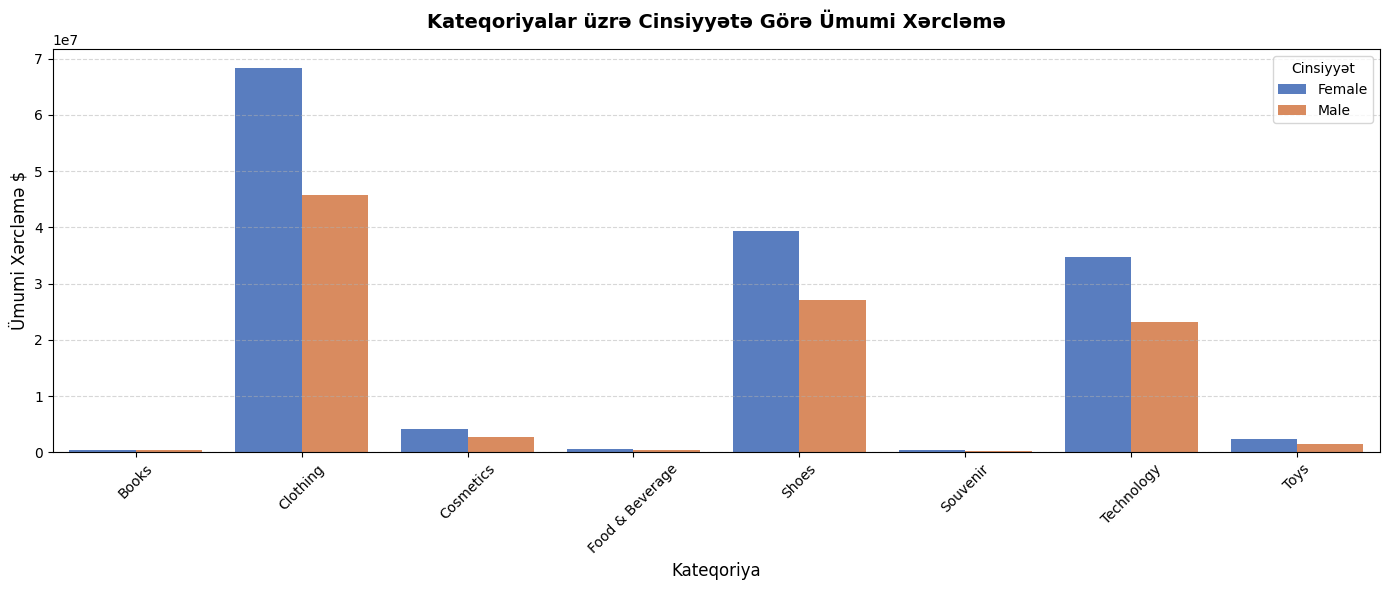

In [69]:
gender_cat = df.groupby(['category', 'gender'])['revenue'].sum().reset_index()


plt.figure(figsize=(14, 6))
sns.barplot(
    data=gender_cat, 
    x='category', 
    y='revenue', 
    hue='gender', 
    palette='muted'
)
plt.title('Kateqoriyalar üzrə Cinsiyyətə Görə Ümumi Xərcləmə', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kateqoriya', fontsize=12)
plt.ylabel('Ümumi Xərcləmə $', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Cinsiyyət')
plt.tight_layout()
plt.show()